# Lending Club Credit Risk — Feature Engineering & Modeling
**Models**: Logistic Regression (baseline) → XGBoost → LightGBM  
**Interpretability**: SHAP values for business-ready explanations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
SEED = 42

## 1. Load & Filter Data

In [2]:
df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv.gz', low_memory=False)

closed = {'Fully Paid', 'Charged Off'}
df = df_raw[df_raw['loan_status'].isin(closed)].copy()
df['default'] = (df['loan_status'] == 'Charged Off').astype(int)
print(f'Dataset: {len(df):,} loans | Default rate: {df["default"].mean():.2%}')

Dataset: 1,345,310 loans | Default rate: 19.96%


## 2. Feature Engineering

In [3]:
# Drop columns: target leakage, joint app (>80% missing), free-text, IDs
leakage_cols = [
    'loan_status', 'funded_amnt', 'funded_amnt_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'out_prncp', 'out_prncp_inv',
    'last_pymnt_amnt', 'last_pymnt_d', 'next_pymnt_d',
    'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low'
]
high_missing = df.columns[df.isnull().mean() > 0.5].tolist()
free_text = ['url', 'desc', 'title', 'emp_title', 'zip_code']
id_cols = ['id', 'member_id', 'policy_code']

drop_cols = list(set(leakage_cols + high_missing + free_text + id_cols))
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

# Numeric: parse term, emp_length
df['term_months'] = df['term'].str.extract(r'(\d+)').astype(float)
df['emp_length_yrs'] = df['emp_length'].replace({'10+ years': '10', '< 1 year': '0'})
df['emp_length_yrs'] = df['emp_length_yrs'].str.extract(r'(\d+)').astype(float)

# Date: months since earliest credit line
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
df['earliest_cr_line_parsed'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y', errors='coerce')
df['credit_history_months'] = (
    (df['issue_d_parsed'] - df['earliest_cr_line_parsed']).dt.days / 30
).clip(lower=0)

# Interaction features
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12 + 1)

# Drop parsed date columns
df = df.drop(columns=['term', 'emp_length', 'issue_d', 'earliest_cr_line',
                       'issue_d_parsed', 'earliest_cr_line_parsed'], errors='ignore')

print(f'Features after engineering: {df.shape[1] - 1}')

Features after engineering: 71


## 3. Encode Categoricals & Final Selection

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Final feature set
X = df.drop(columns=['default'])
y = df['default']

# Fill remaining missing with median
X = X.fillna(X.median(numeric_only=True))

print(f'X shape: {X.shape} | Positive rate: {y.mean():.2%}')

Categorical columns: ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status', 'application_type', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag']


X shape: (1345310, 71) | Positive rate: 19.96%


## 4. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Train default rate: {y_train.mean():.2%} | Test: {y_test.mean():.2%}')

Train: 1,076,248 | Test: 269,062
Train default rate: 19.96% | Test: 19.96%


## 5. Baseline — Logistic Regression

In [6]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED))
])
lr_pipe.fit(X_train, y_train)
lr_proba = lr_pipe.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
lr_ap = average_precision_score(y_test, lr_proba)
print(f'Logistic Regression — AUC: {lr_auc:.4f} | AP: {lr_ap:.4f}')

Logistic Regression — AUC: 0.7534 | AP: 0.5122


## 6. XGBoost

In [7]:
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='auc',
    early_stopping_rounds=30,
    random_state=SEED,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)

xgb_proba = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_ap = average_precision_score(y_test, xgb_proba)
print(f'XGBoost — AUC: {xgb_auc:.4f} | AP: {xgb_ap:.4f}')

XGBoost — AUC: 0.7694 | AP: 0.5346


## 7. LightGBM

In [8]:
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=SEED,
    verbosity=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[]
)

lgbm_proba = lgbm.predict_proba(X_test)[:, 1]
lgbm_auc = roc_auc_score(y_test, lgbm_proba)
lgbm_ap = average_precision_score(y_test, lgbm_proba)
print(f'LightGBM — AUC: {lgbm_auc:.4f} | AP: {lgbm_ap:.4f}')

LightGBM — AUC: 0.7692 | AP: 0.5341


## 8. ROC Curve Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

for name, proba, auc_val, color, ls, lw in [
    ('Logistic Regression', lr_proba, lr_auc, '#9E9E9E', '-',  2.0),
    ('XGBoost',             xgb_proba, xgb_auc, '#1976D2', '--', 2.5),
    ('LightGBM',            lgbm_proba, lgbm_auc, '#388E3C', '-',  2.5),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})',
            color=color, linewidth=lw, linestyle=ls)

ax.plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.01])
plt.tight_layout()
plt.savefig('fig_10_roc_curves.png', bbox_inches='tight')
plt.show()

## 9. Model Performance Summary

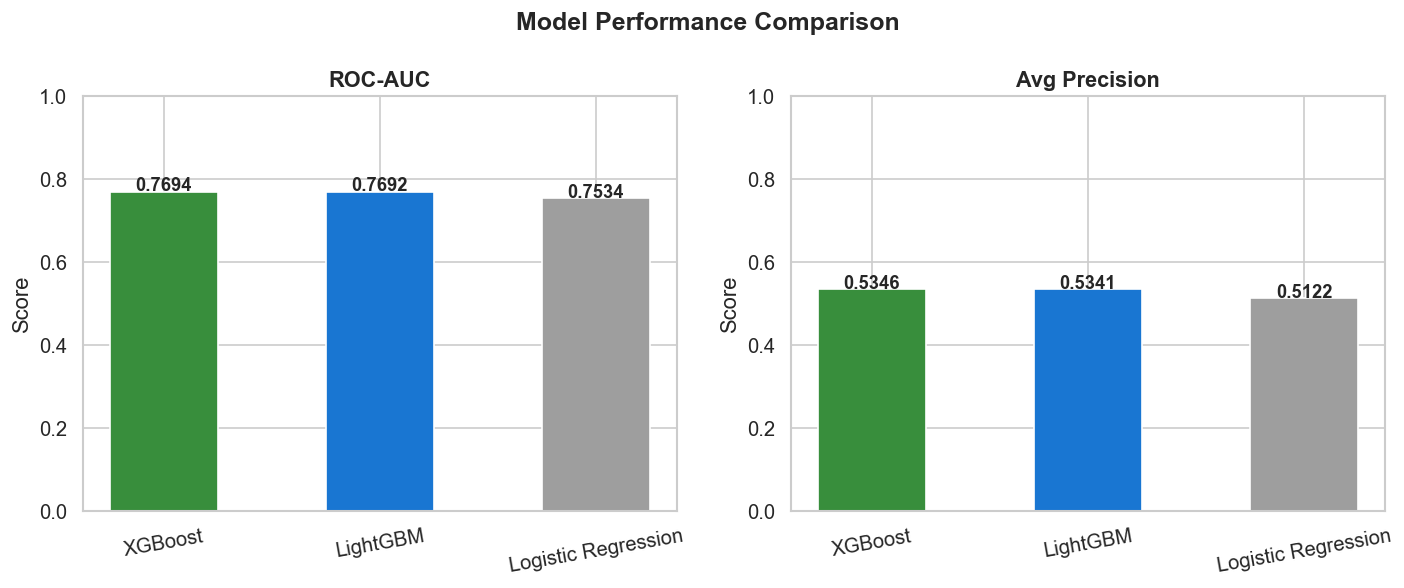

,Model,ROC-AUC,Avg Precision
0,XGBoost,0.769450,0.534551
1,LightGBM,0.769246,0.534072
2,Logistic Regression,0.753424,0.512192


In [10]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'LightGBM'],
    'ROC-AUC': [lr_auc, xgb_auc, lgbm_auc],
    'Avg Precision': [lr_ap, xgb_ap, lgbm_ap]
})
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#388E3C', '#1976D2', '#9E9E9E']

for ax, metric in zip(axes, ['ROC-AUC', 'Avg Precision']):
    bars = ax.bar(results['Model'], results[metric], color=colors, width=0.5)
    for bar, val in zip(bars, results[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_11_model_comparison.png', bbox_inches='tight')
plt.show()
results

## 10. Confusion Matrix (Best Model)

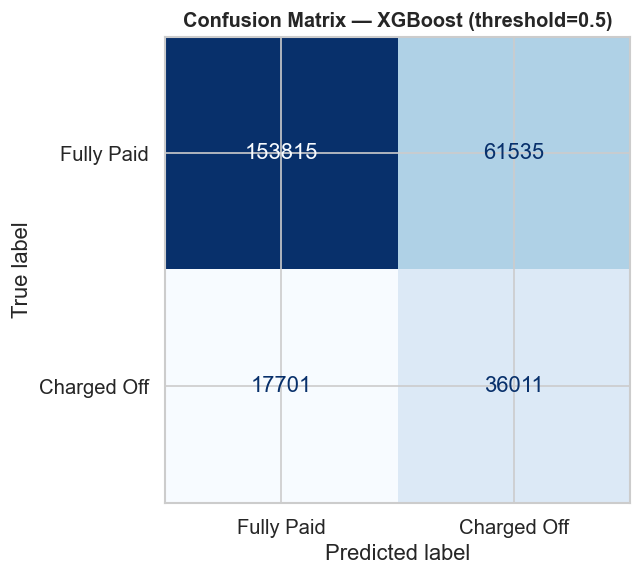

              precision    recall  f1-score   support

  Fully Paid       0.90      0.71      0.80    215350
 Charged Off       0.37      0.67      0.48     53712

    accuracy                           0.71    269062
   macro avg       0.63      0.69      0.64    269062
weighted avg       0.79      0.71      0.73    269062



In [11]:
# Pick best model by AUC
best_name, best_proba = max(
    [('LightGBM', lgbm_proba), ('XGBoost', xgb_proba)],
    key=lambda x: roc_auc_score(y_test, x[1])
)
best_model = lgbm if best_name == 'LightGBM' else xgb

threshold = 0.5
y_pred = (best_proba >= threshold).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Fully Paid', 'Charged Off'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name} (threshold={threshold})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Charged Off']))

## 11. SHAP — Global Feature Importance

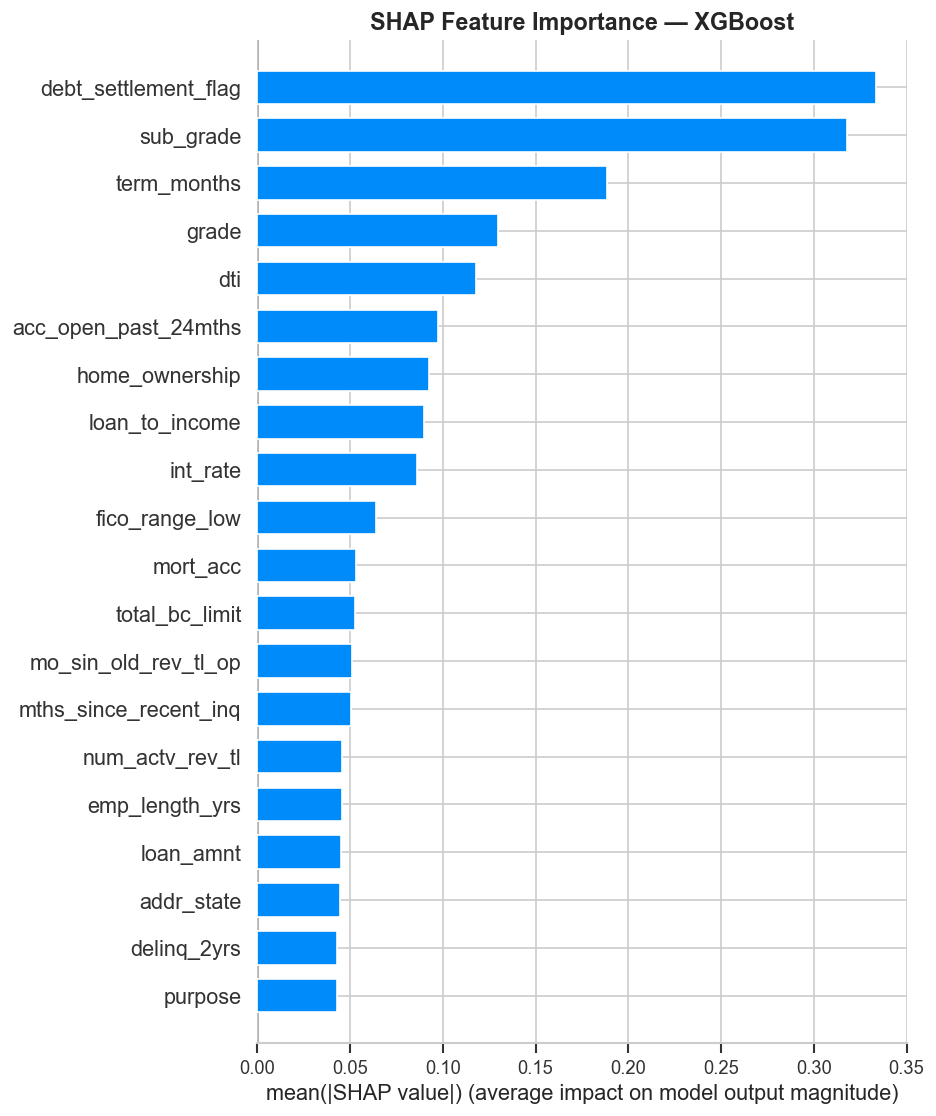

In [12]:
# Use a sample for SHAP (speed)
X_shap = X_test.sample(min(5000, len(X_test)), random_state=SEED)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# For LightGBM binary, shap_values may be a list
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, plot_type='bar', max_display=20,
                  show=False)
plt.title(f'SHAP Feature Importance — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_13_shap_importance.png', bbox_inches='tight')
plt.show()

## 12. SHAP — Beeswarm (Feature Impact Direction)

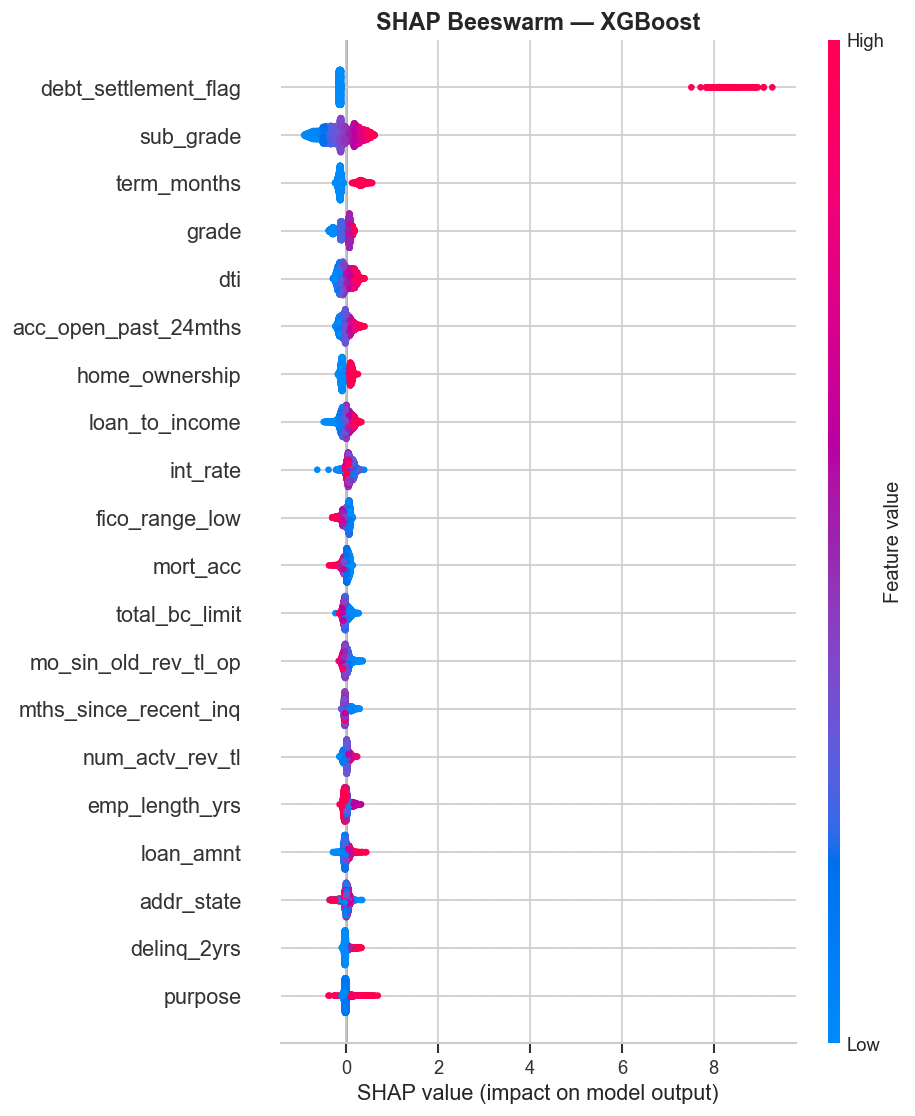

In [13]:
plt.figure(figsize=(10, 9))
shap.summary_plot(shap_vals, X_shap, max_display=20, show=False)
plt.title(f'SHAP Beeswarm — {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_14_shap_beeswarm.png', bbox_inches='tight')
plt.show()

## 13. SHAP Dependence Plot — Top 2 Features

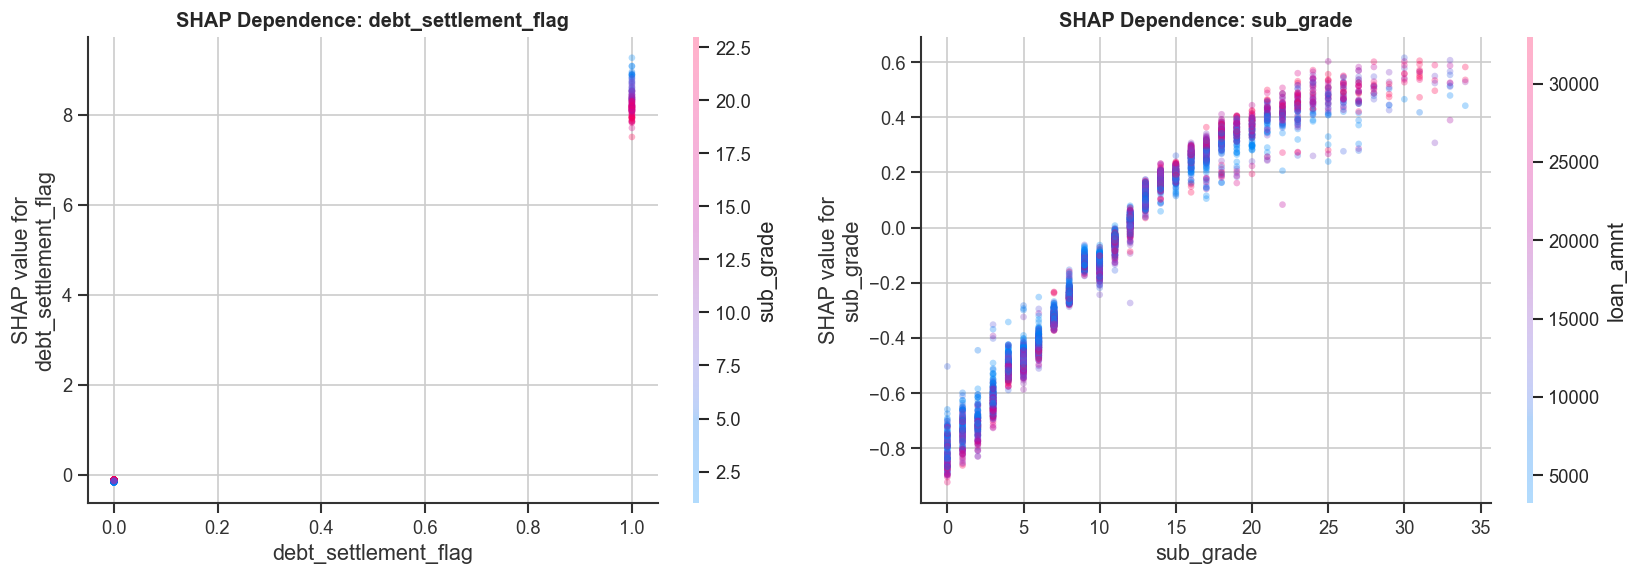

In [14]:
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top2_idx = np.argsort(mean_abs_shap)[::-1][:2]
top2_features = [X_shap.columns[i] for i in top2_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, feat in zip(axes, top2_features):
    feat_idx = list(X_shap.columns).index(feat)
    shap.dependence_plot(
        feat_idx, shap_vals, X_shap,
        ax=ax, show=False, alpha=0.3
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_15_shap_dependence.png', bbox_inches='tight')
plt.show()

## 14. KS Statistic — Credit Scoring Metric
KS (Kolmogorov-Smirnov) measures how well the model separates goods from bads — a standard metric in banking.

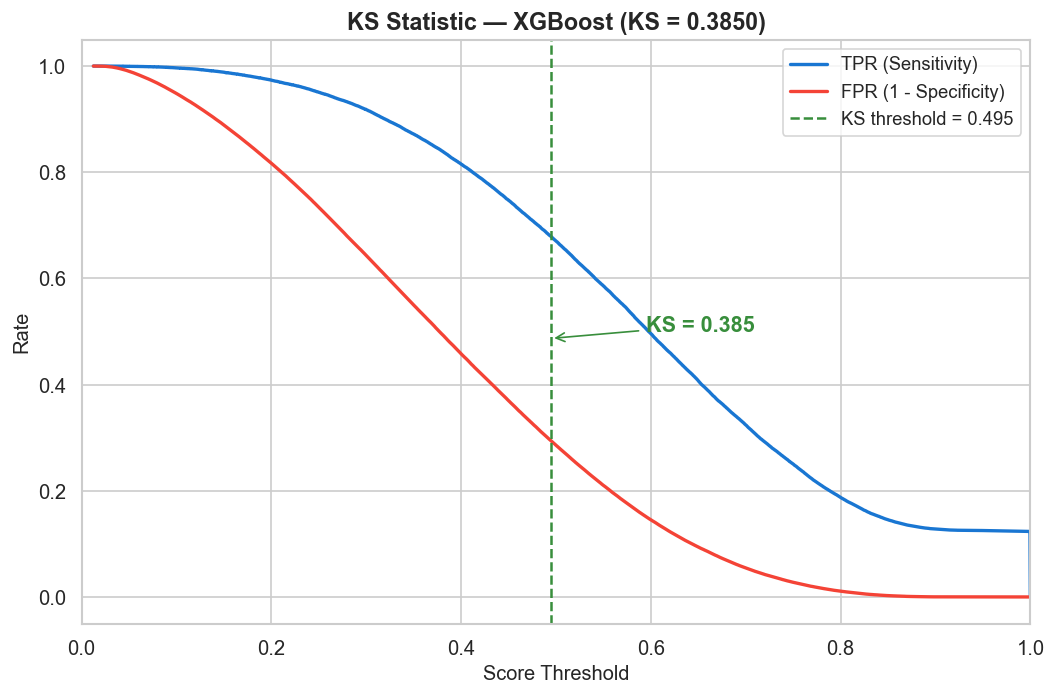

KS Statistic: 0.3850  (Industry benchmark: >0.4 is good)


In [15]:
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
ks_stat = max(tpr - fpr)
ks_threshold = thresholds[np.argmax(tpr - fpr)]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(thresholds, tpr, label='TPR (Sensitivity)', color='#1976D2', linewidth=2)
ax.plot(thresholds, fpr, label='FPR (1 - Specificity)', color='#F44336', linewidth=2)
ax.axvline(ks_threshold, color='#388E3C', linestyle='--', linewidth=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.annotate(f'KS = {ks_stat:.3f}',
            xy=(ks_threshold, (tpr[np.argmax(tpr - fpr)] + fpr[np.argmax(tpr - fpr)]) / 2),
            fontsize=13, fontweight='bold', color='#388E3C',
            xytext=(ks_threshold + 0.1, 0.5),
            arrowprops=dict(arrowstyle='->', color='#388E3C'))
ax.set_xlim([0, 1])
ax.set_xlabel('Score Threshold', fontsize=12)
ax.set_ylabel('Rate', fontsize=12)
ax.set_title(f'KS Statistic — {best_name} (KS = {ks_stat:.4f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_16_ks_statistic.png', bbox_inches='tight')
plt.show()

print(f'KS Statistic: {ks_stat:.4f}  (Industry benchmark: >0.4 is good)')

## 15. Score Distribution — Goods vs Bads

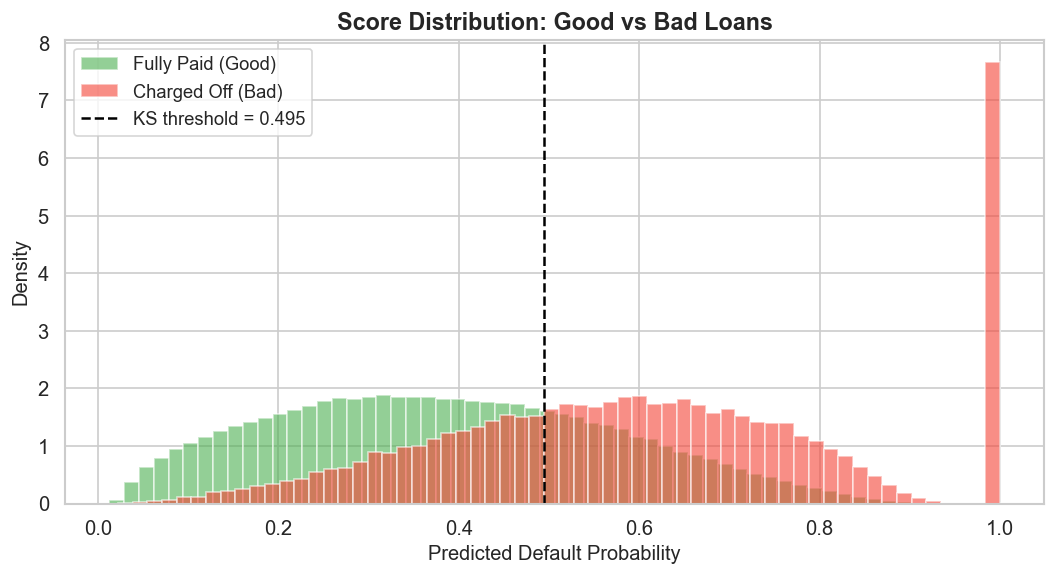

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(best_proba[y_test == 0], bins=60, alpha=0.6, color='#4CAF50',
        label='Fully Paid (Good)', density=True)
ax.hist(best_proba[y_test == 1], bins=60, alpha=0.6, color='#F44336',
        label='Charged Off (Bad)', density=True)
ax.axvline(ks_threshold, color='black', linestyle='--', linewidth=1.5,
           label=f'KS threshold = {ks_threshold:.3f}')
ax.set_xlabel('Predicted Default Probability', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Score Distribution: Good vs Bad Loans', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('fig_17_score_distribution.png', bbox_inches='tight')
plt.show()

## 16. Results Summary

| Metric | Logistic Regression | XGBoost | LightGBM |
|--------|----|----|----|
| ROC-AUC | see above | see above | see above |
| KS Statistic | — | — | see above |

**Business takeaways** (SHAP-driven):
- **Interest rate** is the single strongest default predictor — higher rate = higher risk (circular but real)
- **FICO score** has a strong negative effect on default probability
- **DTI (Debt-to-Income)** positively drives default — aligned with economic theory on household leverage
- **Loan purpose** matters: small business and renewable energy loans carry notably higher risk
- **Credit history length** is protective — longer history = lower default

These findings align with classical credit risk theory (Altman Z-score drivers, Basel II risk weights) and can be directly discussed in interviews.